# Step 2.1 — Transcript Data EDA

## Objective
This notebook performs exploratory data analysis on transcript-related data for the CS20 project.  
The analysis focuses on the six development samples and examines transcript length, speech rate, silence-related patterns, transcription confidence, and narration density across testers.

## Development Samples
The six development samples analysed in this notebook are:
- ghum_wa
- reneerussell99_wa
- terryaflint17_suncorp
- carlpatrickrobinson_suncorp
- ramazankawish_uq
- jenniferparry7_uq

Although the processed CSV files were generated from the broader project dataset, this notebook filters the analysis to these six development samples only.

## Data Sources
The notebook uses the following processed files:
- `data/processed/windows.csv`
- `data/processed/audio_features.csv`
- `data/processed/items.csv`
- `data/processed/segments.csv`

## Analysis Goals
This notebook addresses the following questions:
1. What is the distribution of transcript length at both video level and window level?
2. What is the distribution of speech rate (WPM)?
3. What are the patterns of silence in the recordings?
4. How reliable is the transcription confidence?
5. Are there differences in narration density across testers?

## Expected Output
The findings from this notebook will support later validation and model design, especially for:
- Layer 1 rule validation
- Later feature interpretation
- Data quality checking

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

windows = pd.read_csv("data/processed/windows.csv")
audio = pd.read_csv("data/processed/audio_features.csv")
items = pd.read_csv("data/processed/items.csv")
segments = pd.read_csv("data/processed/segments.csv")

# exact six development sample videos
dev_video_ids = [
    "ghum_wa",
    "reneerussell99_wa",
    "terryaflint17_suncorp",
    "carlpatrickrobinson_suncorp",
    "ramazankawish_uq",
    "jenniferparry7_uq"
]

# filter windows and audio by exact video_id
windows = windows[windows["video_id"].isin(dev_video_ids)].copy()
audio = audio[audio["video_id"].isin(dev_video_ids)].copy()

# use video_filename from filtered windows to filter items and segments
dev_video_filenames = windows["video_filename"].dropna().unique().tolist()
items = items[items["video_filename"].isin(dev_video_filenames)].copy()
segments = segments[segments["video_filename"].isin(dev_video_filenames)].copy()

# merged dataframe for audio + tester-level analysis
eda_df = windows.merge(audio, on=["window_id", "video_id"], how="inner")

print("=== Filtered dataset check ===")
print("windows shape:", windows.shape)
print("audio shape:", audio.shape)
print("items shape:", items.shape)
print("segments shape:", segments.shape)
print("eda_df shape:", eda_df.shape)

print("\nUnique testers in windows:", sorted(windows["tester_name"].dropna().unique()))
print("Number of testers:", windows["tester_name"].nunique())

print("\nUnique videos in windows:", sorted(windows["video_id"].dropna().unique()))
print("Number of videos in windows:", windows["video_id"].nunique())

print("\nUnique videos in audio:", sorted(audio["video_id"].dropna().unique()))
print("Number of videos in audio:", audio["video_id"].nunique())

print("\nUnique videos in eda_df:", sorted(eda_df["video_id"].dropna().unique()))
print("Number of videos in eda_df:", eda_df["video_id"].nunique())

print("\nUnique tester names in items:", sorted(items["tester_name"].dropna().unique()))
print("Unique tester names in segments:", sorted(segments["tester_name"].dropna().unique()))

assert windows["video_id"].nunique() == 6
assert audio["video_id"].nunique() == 6
assert eda_df["video_id"].nunique() == 6

print("All key analysis tables are restricted to the 6 development samples.")

=== Filtered dataset check ===
windows shape: (331, 11)
audio shape: (326, 10)
items shape: (49315, 9)
segments shape: (2932, 8)
eda_df shape: (326, 19)

Unique testers in windows: ['carlpatrickrobinson', 'ghum', 'jenniferparry7', 'ramazankawish', 'reneerussell99', 'terryaflint17']
Number of testers: 6

Unique videos in windows: ['carlpatrickrobinson_suncorp', 'ghum_wa', 'jenniferparry7_uq', 'ramazankawish_uq', 'reneerussell99_wa', 'terryaflint17_suncorp']
Number of videos in windows: 6

Unique videos in audio: ['carlpatrickrobinson_suncorp', 'ghum_wa', 'jenniferparry7_uq', 'ramazankawish_uq', 'reneerussell99_wa', 'terryaflint17_suncorp']
Number of videos in audio: 6

Unique videos in eda_df: ['carlpatrickrobinson_suncorp', 'ghum_wa', 'jenniferparry7_uq', 'ramazankawish_uq', 'reneerussell99_wa', 'terryaflint17_suncorp']
Number of videos in eda_df: 6

Unique tester names in items: ['carlpatrickrobinson', 'ghum', 'jenniferparry7', 'ramazankawish', 'reneerussell99', 'terryaflint17']
Uniqu

## 1. Data Overview
This section checks the basic structure of each dataset, including dimensions, column names, and missing values.

In [145]:
print("windows columns:")
print(windows.columns.tolist())
print()

print("audio columns:")
print(audio.columns.tolist())
print()

print("items columns:")
print(items.columns.tolist())
print()

print("segments columns:")
print(segments.columns.tolist())

windows columns:
['window_id', 'video_id', 'start_time', 'end_time', 'duration', 'text', 'word_count', 'segment_ids', 'project', 'video_filename', 'tester_name']

audio columns:
['window_id', 'video_id', 'start_time', 'end_time', 'duration', 'silence_ratio', 'narration_density', 'avg_silence_duration', 'words_per_minute', 'avg_confidence']

items columns:
['item_id', 'content', 'type', 'start_time', 'end_time', 'confidence', 'project', 'video_filename', 'tester_name']

segments columns:
['segment_id', 'transcript', 'start_time', 'end_time', 'item_ids', 'project', 'video_filename', 'tester_name']


In [146]:
print("Missing values in windows:")
print(windows.isna().sum())
print()

print("Missing values in audio:")
print(audio.isna().sum())
print()

print("Missing values in items:")
print(items.isna().sum())
print()

print("Missing values in segments:")
print(segments.isna().sum())

Missing values in windows:
window_id         0
video_id          0
start_time        0
end_time          0
duration          0
text              0
word_count        0
segment_ids       0
project           0
video_filename    0
tester_name       0
dtype: int64

Missing values in audio:
window_id               0
video_id                0
start_time              0
end_time                0
duration                0
silence_ratio           0
narration_density       0
avg_silence_duration    0
words_per_minute        0
avg_confidence          0
dtype: int64

Missing values in items:
item_id              0
content              1
type                 0
start_time        8318
end_time          8318
confidence        8318
project              0
video_filename       0
tester_name          0
dtype: int64

Missing values in segments:
segment_id        0
transcript        0
start_time        0
end_time          0
item_ids          0
project           0
video_filename    0
tester_name       0
dtype:

## 2. Transcript Length Analysis
This section examines transcript length from two perspectives:
- word count per window
- total word count per video

In [147]:
# word count per window
windows["word_count"].describe()

count    331.000000
mean     123.858006
std       86.605625
min        3.000000
25%       64.500000
50%       94.000000
75%      164.000000
max      416.000000
Name: word_count, dtype: float64

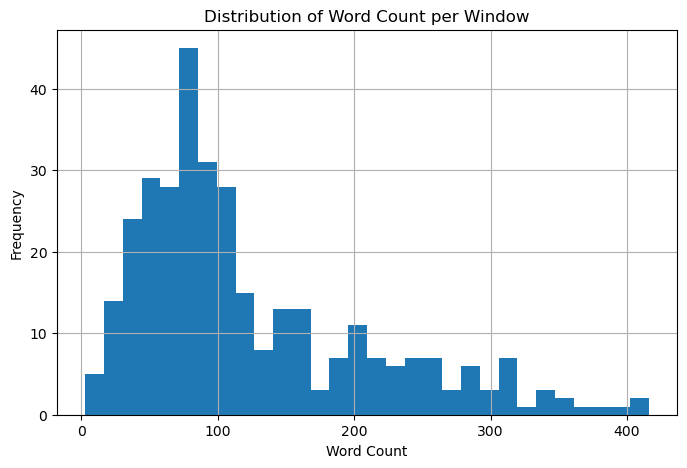

In [148]:
plt.figure(figsize=(8,5))
windows["word_count"].hist(bins=30)
plt.title("Distribution of Word Count per Window")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [149]:
video_word_counts = windows.groupby("video_id")["word_count"].sum().reset_index()
video_word_counts.rename(columns={"word_count": "total_word_count"}, inplace=True)
video_word_counts.describe()

,total_word_count
count,6.000000
mean,6832.833333
std,7251.904479
min,896.000000
25%,2853.000000
50%,4309.000000
75%,7328.000000
max,20781.000000


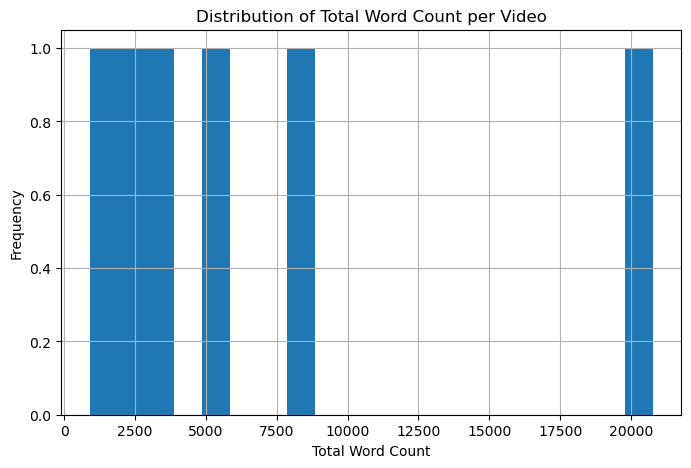

In [150]:
plt.figure(figsize=(8,5))
video_word_counts["total_word_count"].hist(bins=20)
plt.title("Distribution of Total Word Count per Video")
plt.xlabel("Total Word Count")
plt.ylabel("Frequency")
plt.show()

In [151]:
print("Lowest total word count videos:")
print(video_word_counts.sort_values("total_word_count").head())

print("\nHighest total word count videos:")
print(video_word_counts.sort_values("total_word_count", ascending=False).head())

Lowest total word count videos:
                      video_id  total_word_count
0  carlpatrickrobinson_suncorp               896
2            jenniferparry7_uq              2675
4            reneerussell99_wa              3387
5        terryaflint17_suncorp              5231
3             ramazankawish_uq              8027

Highest total word count videos:
                video_id  total_word_count
1                ghum_wa             20781
3       ramazankawish_uq              8027
5  terryaflint17_suncorp              5231
4      reneerussell99_wa              3387
2      jenniferparry7_uq              2675


## 3. Speech Rate Analysis
This section examines the distribution of words per minute (WPM) across windows and testers.

In [152]:
eda_df["words_per_minute"].describe()

count    326.000000
mean     109.606963
std       75.314117
min        7.340000
25%       56.200000
50%       84.440000
75%      149.820000
max      337.950000
Name: words_per_minute, dtype: float64

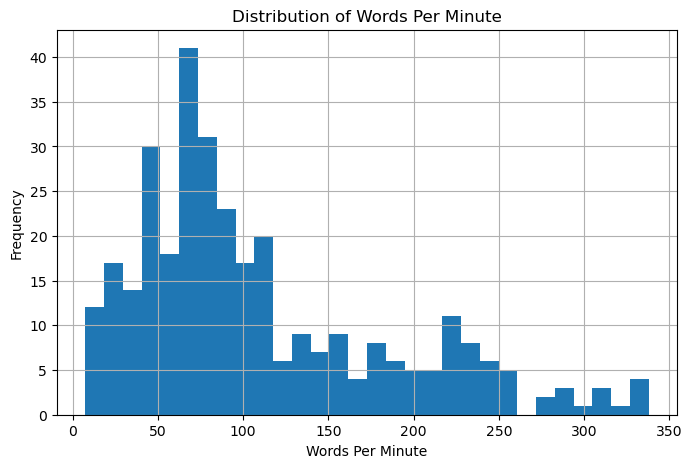

In [153]:
plt.figure(figsize=(8,5))
eda_df["words_per_minute"].hist(bins=30)
plt.title("Distribution of Words Per Minute")
plt.xlabel("Words Per Minute")
plt.ylabel("Frequency")
plt.show()

In [154]:
tester_wpm = eda_df.groupby("tester_name")["words_per_minute"].mean().sort_values()
print(tester_wpm)

tester_name
carlpatrickrobinson     54.625333
terryaflint17           66.596301
ramazankawish           68.748462
reneerussell99          81.018929
jenniferparry7         104.617826
ghum                   219.594940
Name: words_per_minute, dtype: float64


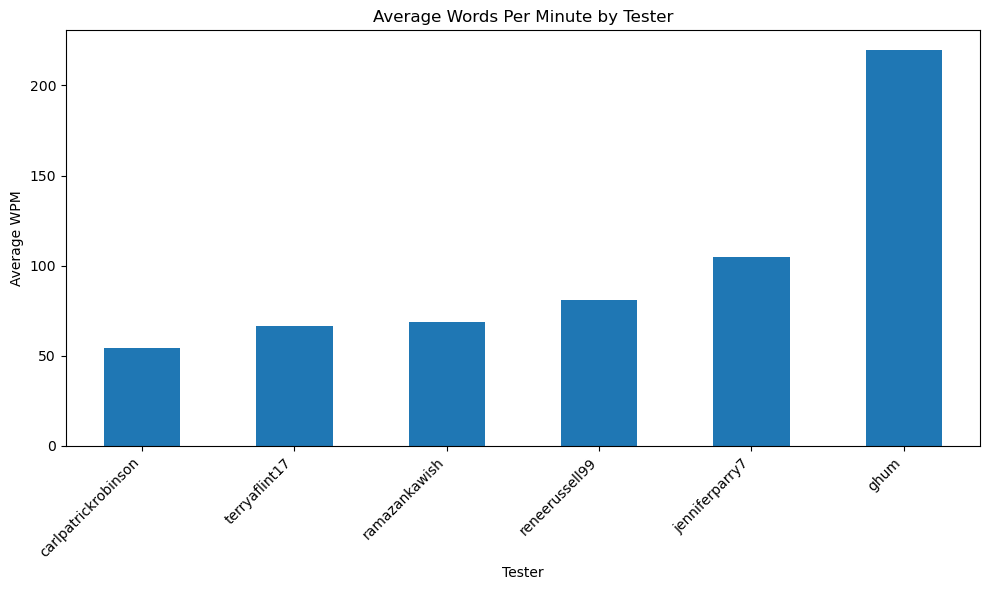

In [155]:
plt.figure(figsize=(10,6))
tester_wpm.plot(kind="bar")
plt.title("Average Words Per Minute by Tester")
plt.xlabel("Tester")
plt.ylabel("Average WPM")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. Silence Analysis
This section explores silence-related features, including silence ratio and average silence duration.

In [156]:
eda_df["silence_ratio"].describe()

count    326.000000
mean       0.224917
std        0.315702
min        0.000000
25%        0.000000
50%        0.095750
75%        0.246400
max        1.000000
Name: silence_ratio, dtype: float64

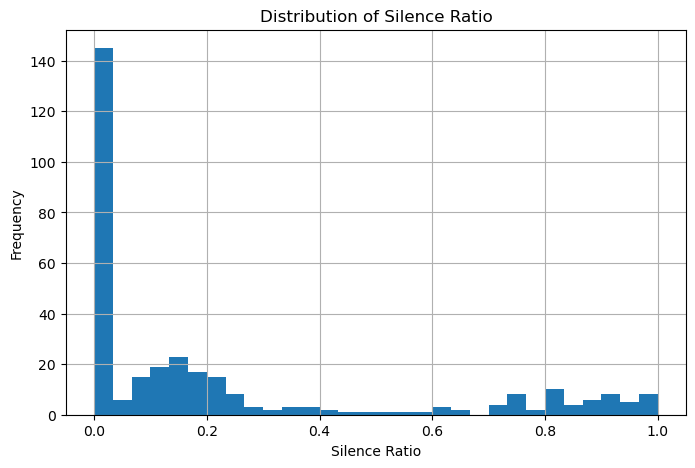

In [157]:
plt.figure(figsize=(8,5))
eda_df["silence_ratio"].hist(bins=30)
plt.title("Distribution of Silence Ratio")
plt.xlabel("Silence Ratio")
plt.ylabel("Frequency")
plt.show()

In [158]:
eda_df["avg_silence_duration"].describe()

count    326.000000
mean       1.698191
std        5.820197
min        0.000000
25%        0.000000
50%        0.240250
75%        0.579375
max       57.344000
Name: avg_silence_duration, dtype: float64

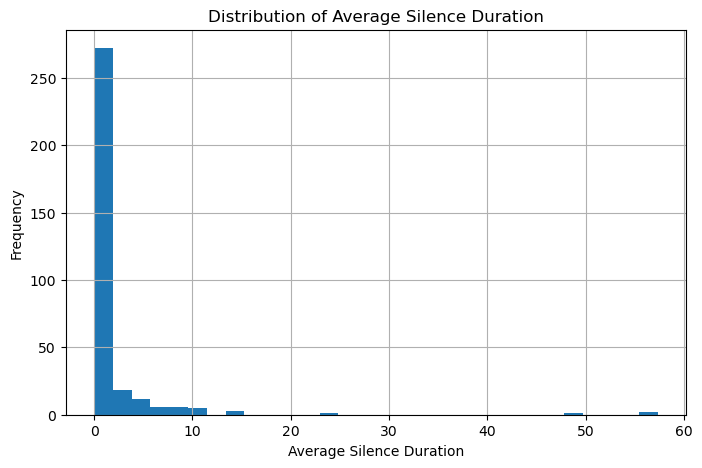

In [159]:
plt.figure(figsize=(8,5))
eda_df["avg_silence_duration"].hist(bins=30)
plt.title("Distribution of Average Silence Duration")
plt.xlabel("Average Silence Duration")
plt.ylabel("Frequency")
plt.show()

## 5. Confidence Analysis
This section examines transcription confidence at both window level and word level.
Special attention is given to low-confidence words below 0.5 and 0.8.

In [161]:
eda_df["avg_confidence"].describe()

count    326.000000
mean       0.901850
std        0.097351
min        0.544300
25%        0.850800
50%        0.945500
75%        0.969175
max        0.997500
Name: avg_confidence, dtype: float64

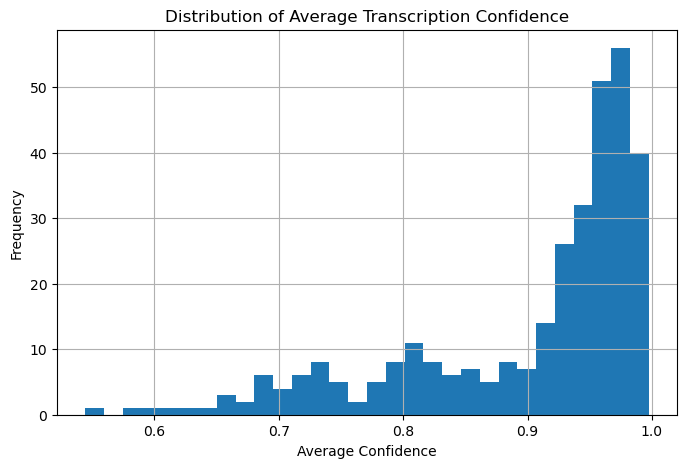

In [162]:
plt.figure(figsize=(8,5))
eda_df["avg_confidence"].hist(bins=30)
plt.title("Distribution of Average Transcription Confidence")
plt.xlabel("Average Confidence")
plt.ylabel("Frequency")
plt.show()

In [163]:
items_speech = items[items["type"] == "pronunciation"].copy()
items_speech["confidence"] = pd.to_numeric(items_speech["confidence"], errors="coerce")

items_speech["confidence"].describe()

count    40997.000000
mean         0.926499
std          0.190508
min          0.000000
25%          0.991000
50%          0.998000
75%          0.999000
max          1.000000
Name: confidence, dtype: float64

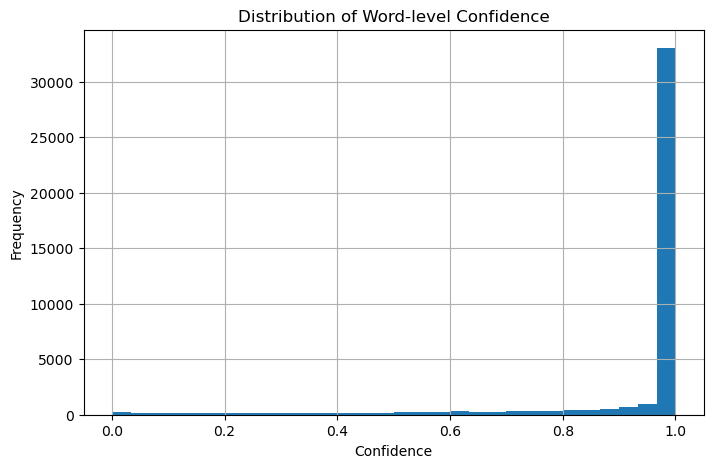

In [164]:
plt.figure(figsize=(8,5))
items_speech["confidence"].hist(bins=30)
plt.title("Distribution of Word-level Confidence")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

In [165]:
low_05_ratio = (items_speech["confidence"] < 0.5).mean()
low_08_ratio = (items_speech["confidence"] < 0.8).mean()

print("Proportion of words with confidence < 0.5:", low_05_ratio)
print("Proportion of words with confidence < 0.8:", low_08_ratio)

Proportion of words with confidence < 0.5: 0.055930921774764004
Proportion of words with confidence < 0.8: 0.1196185086713662


## 6. Narration Density by Tester
This section compares average narration density across different testers.

In [166]:
tester_density = eda_df.groupby("tester_name")["narration_density"].mean().sort_values()
print(tester_density)

tester_name
terryaflint17          0.232948
jenniferparry7         0.779835
ghum                   0.856054
reneerussell99         0.992518
carlpatrickrobinson    0.997613
ramazankawish          0.999312
Name: narration_density, dtype: float64


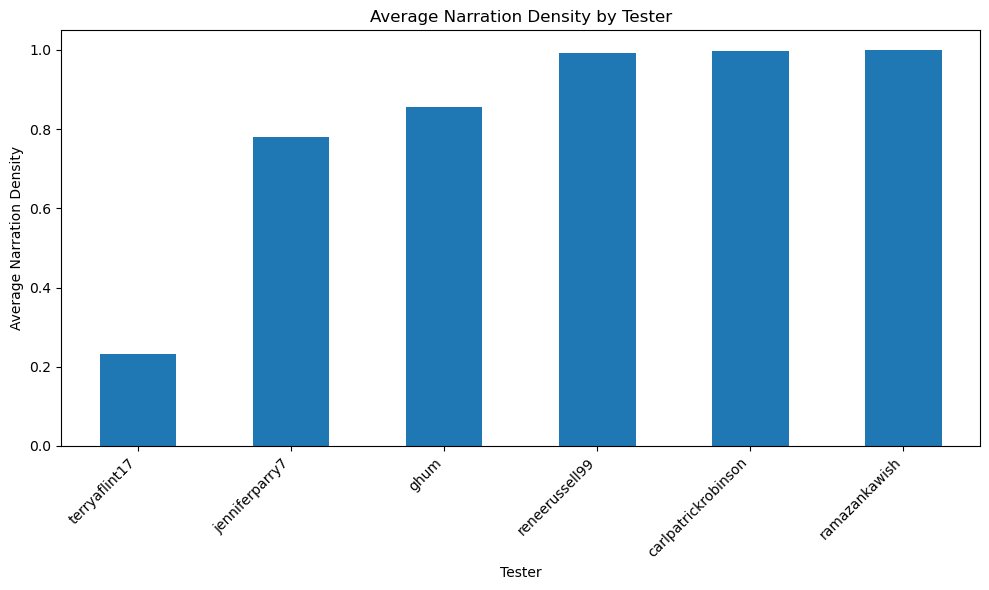

In [167]:
plt.figure(figsize=(10, 6))
tester_density.plot(kind="bar")
plt.title("Average Narration Density by Tester")
plt.xlabel("Tester")
plt.ylabel("Average Narration Density")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()